# Load QICK

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_4ce8cf0b4edf4470a598e5d1b1c2bc45@192.168.10.82:44717
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.

# Qubit Setting

In [2]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.system_cfg import config_list

qubit = "Q1"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# TOF

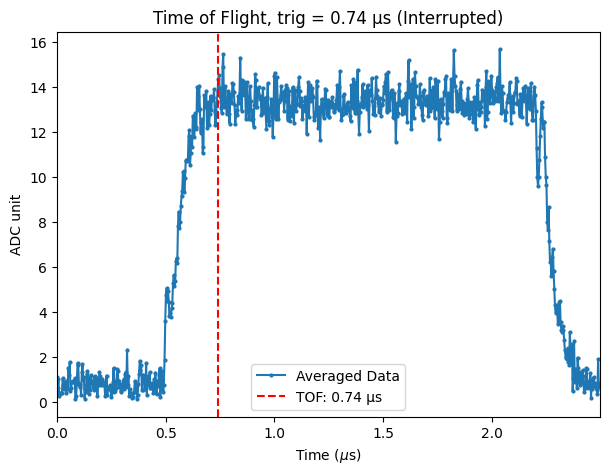

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0401\s001_tof_Q1_004


In [117]:
from qick_workspace.newscrip.s001_time_of_flight import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    {
        # "res_freq_ge": 3400,
        "ro_length": 2.5,
        "res_length": 1.7,
        "res_gain_ge": 0.18,
        "res_ch": 0,
        "cheek_e": False,
        "check_f": True,
        "relax_delay": 100,
    }
)

tof = TOF(soc, soccfg, run_cfg)
tof.run(1000)
tof.saveLabber(qubit)


In [3]:
config_all.update("trig_time", 0.49, q_index=qubit)

# YOKO Setting

In [ ]:
# from qick_workspace.tools.YOKOGS200 import YOKOGS200
# import pyvisa

# rm = pyvisa.ResourceManager()
# yoko_connect = "USB0::0x0B21::0x0039::90ZB35281::INSTR"
# yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()
# yoko.OutputOff()

## Current mode

In [8]:
# yoko.SetMode("current")
# yokocurrent = 1 * 1e-3
# yoko.SetCurrent(yokocurrent)
# yoko.GetValue()

## Voltage mode

In [ ]:
# yoko.SetMode("voltage")
# yoko_value = -12.6
# yoko.SetVoltage(yoko_value, _rampstep=1e-2)
# print(yoko.GetValue())
# yoko_value = yoko.GetValue()

# GE State

## Resonator OneTone

c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': np.float64(6.723),
 'Qi': -1810,
 'Ql': 1721,
 'absQc': 882,
 'κ(MHz)': np.float64(3.91)}


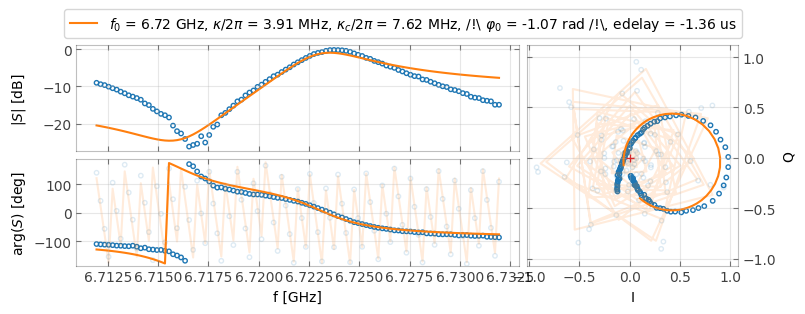

In [23]:
from qick_workspace.newscrip.s002_res_spec_ge import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]


STEPS = 101

config_all.update("res.res_gain_ge", 0.05, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(soc, soccfg, run_cfg)
fres = onetone.run(py_avg=5, solve_type="hm")
## update value ##
config_all.update("res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

In [337]:
onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0331\s002_onetone_ge_Q2_002


## OneTone PunchOut

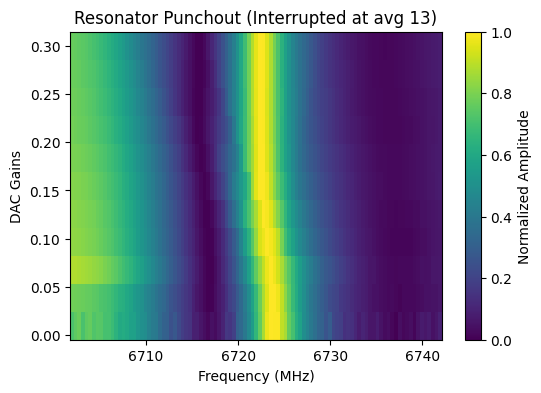

Experiment interrupted at 13 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s002b_res_ge_punchout_Q1_001


In [22]:
from qick_workspace.newscrip.s002b_res_punchout_ge import Punchout

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 20  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 20  # [MHz]



STEPS_freq = 101

START_gain = 0.01
STOP_gain = 0.3
STEPS_gain = 11

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("f_steps", STEPS_freq),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("g_steps", STEPS_gain),
        ("res_gain_ge", QickSweep1D("gainloop", START_gain, STOP_gain)),
        ("relax_delay", 0),
    ]
)
punchout = Punchout(soc, soccfg, run_cfg)
punchout.run(py_avg=100, show_final_plot=True)
punchout.saveLabber(qubit, config_all=config_all)

## Qubit Spectrum ge

Experiment interrupted at 18 averages. Fit is based on partial data.


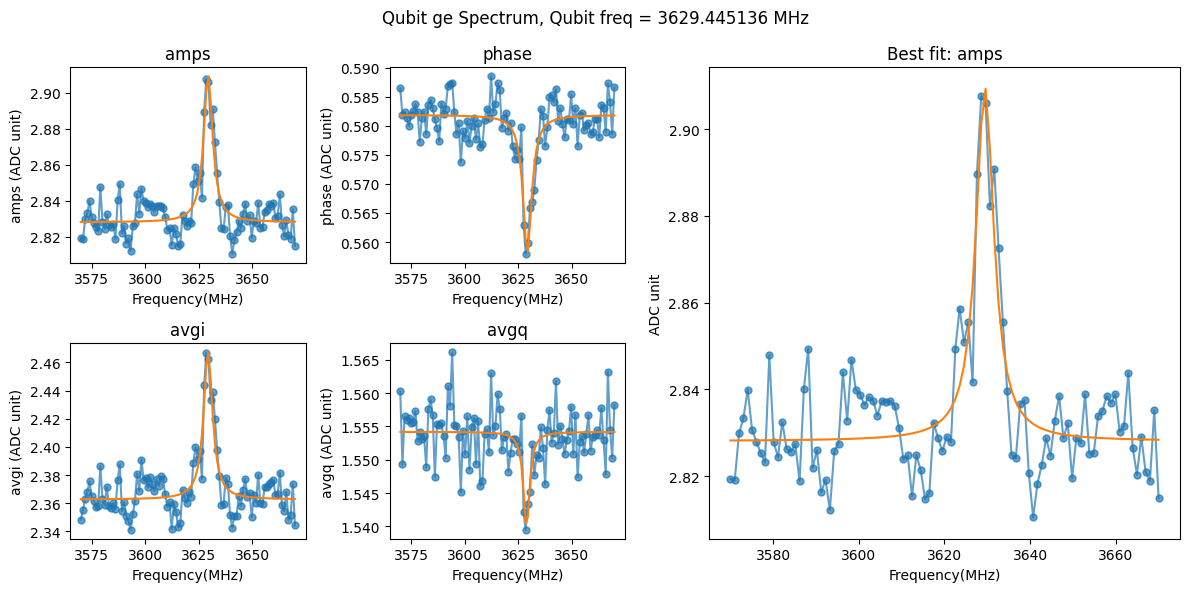

In [5]:
from qick_workspace.newscrip.s003_qubit_spec_ge import QubitSpec

center = 3620
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 100

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.1),
        ("qb_flat_top_length_ge", 5),
        ("relax_delay", 1),
        ("nqz_qb", 2),
    ]
)

spectrum_ge = QubitSpec(soc, soccfg, run_cfg)
f_ge = spectrum_ge.run(100)
config_all.update("qb_freq_ge", f_ge, q_index=qubit)
config_all.update("qb_mixer", f_ge, q_index=qubit)

In [237]:
spectrum_ge.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0330\s003_qubit_spec_ge_Q2_003


### Fast flux spectrum

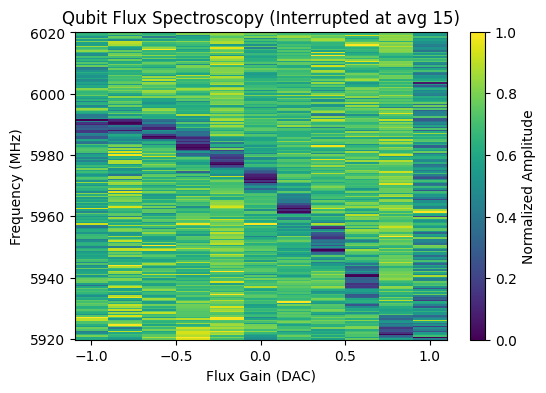

Experiment interrupted at 15 averages. Fit is based on partial data.


In [ ]:
from qick_workspace.newscrip.s003a_qubit_flux_spec_ge import QubitSpecFlux

center = 5970
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201

START_GAIN = -1
STOP_GAIN = 1
STEPS_GAIN = 11

config_all.update("qb_ch", 2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.3),
        ("qb_flat_top_length_ge", 0.5),
        ("relax_delay", 1),
        ("nqz_qb", 2),
        ("res_length", 3),
        ("ro_length", 2.478),
        ("res_gain_ge", 0.95),
        ###################
        ("flux_ch", 15),
        ("flux_gain", QickSweep1D("fluxloop", START_GAIN, STOP_GAIN)),
        ("steps_flux", STEPS_GAIN),
        ("flux_length", 0.7),
    ]
)

spectrumff_ge = QubitSpecFlux(soc, soccfg, run_cfg)
spectrumff_ge.run(500, swap_xy=True, show_final_plot=True)


## Time Rabi ge

Experiment interrupted at 33 averages. Fit is based on partial data.


(np.float64(0.006415584088129531), np.float64(0.0019565014963671733))

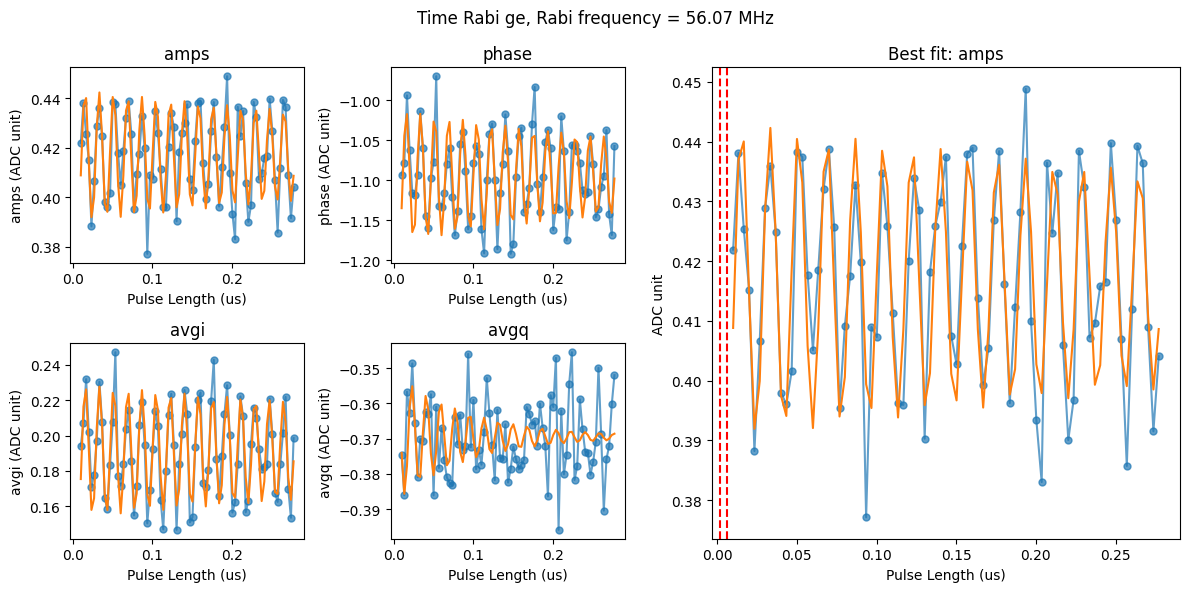

In [ ]:
from qick_workspace.newscrip.s004_time_rabi_ge import TimeRabi


config_all.update("sigma_ge", 0.01, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("cooling", False),
        ("qb_gain_ge", 0.5),
        ("qb_flat_top_length_ge", QickSweep1D("lenloop", 0.01, 0.3)),
        ("steps", 81),
    ]
)

Trabi = TimeRabi(soc, soccfg, run_cfg)
Trabi.run(100)
# Trabi.saveLabber(qubit, yoko_value=yoko_value)

## Power Rabi ge

Experiment interrupted at 4 averages. Fit is based on partial data.


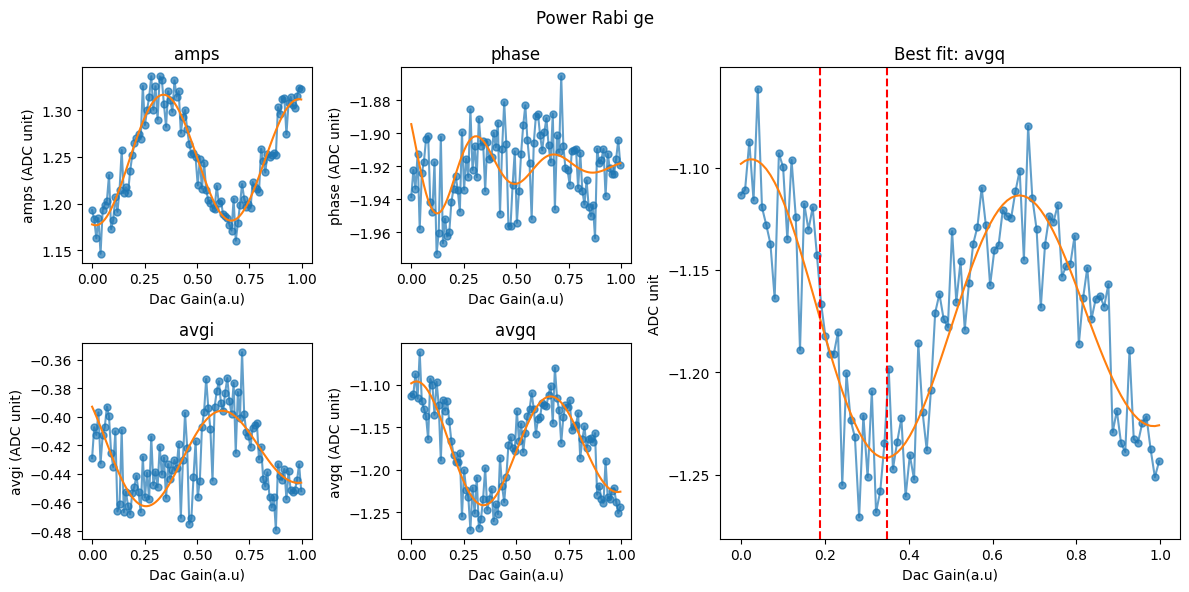

In [61]:
from qick_workspace.newscrip.s005_power_rabi_ge import PowerRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ge", 0.01, q_index=qubit)
config_all.update("nqz_qb", 2, q_index=qubit)
config_all.update("relax_delay", 200, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("pulse_type", "drag"),
        # ("qb_flat_top_length_ge", 0.1),
    ]
)

prabi = PowerRabi(soc, soccfg, run_cfg)
pi_gain, pi2_gain = prabi.run(20)
config_all.update("pi_gain_ge", pi_gain, q_index=qubit)
config_all.update("pi2_gain_ge", pi2_gain, q_index=qubit)

In [256]:
prabi.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0330\s005_power_rabi_ge_Q3_004


## Amplified Amplitude Error (AAE)


[PowerRabi] Optimal pi gain = 0.311573


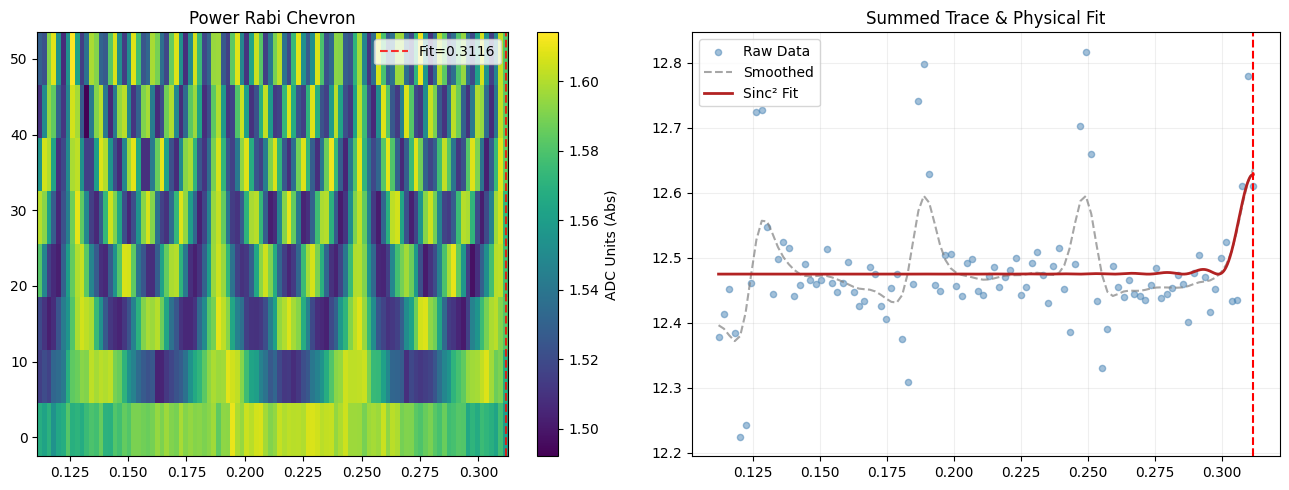

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0407\s005_power_rabi_chevron_Q1_008


In [151]:
from qick_workspace.newscrip.s005a_AAE import PowerRabiChevron

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

run_cfg = config_all.get_qubit(qubit)
focus = run_cfg['pi_gain_ge']
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", focus-0.1, focus+0.1)),
        ("pulse_type", "drag"),
        ("iter_start", 1),
        ("iter_stop", 50),
        ("iter_step", 7),
        # ("qb_flat_top_length_ge", 0.1),

    ]
)

prabichevron = PowerRabiChevron(soc, soccfg, run_cfg)
result = prabichevron.run(10)
config_all.update("pi_gain_ge", result, q_index=qubit)
config_all.update("pi2_gain_ge", result / 2, q_index=qubit)
prabichevron.saveLabber(qubit, config_all=config_all)

## Ramsey ge

Experiment interrupted at 6 averages. Fit is based on partial data.


(array([ 1.23708182e-01,  1.99678018e+00,  2.21331124e+02,  2.90828449e+06,
        -3.10469952e-01]),
 array([1.83027668e-03, 4.62437835e-03, 1.84747201e+00, 1.21489476e-12,
        1.31743109e-03]))

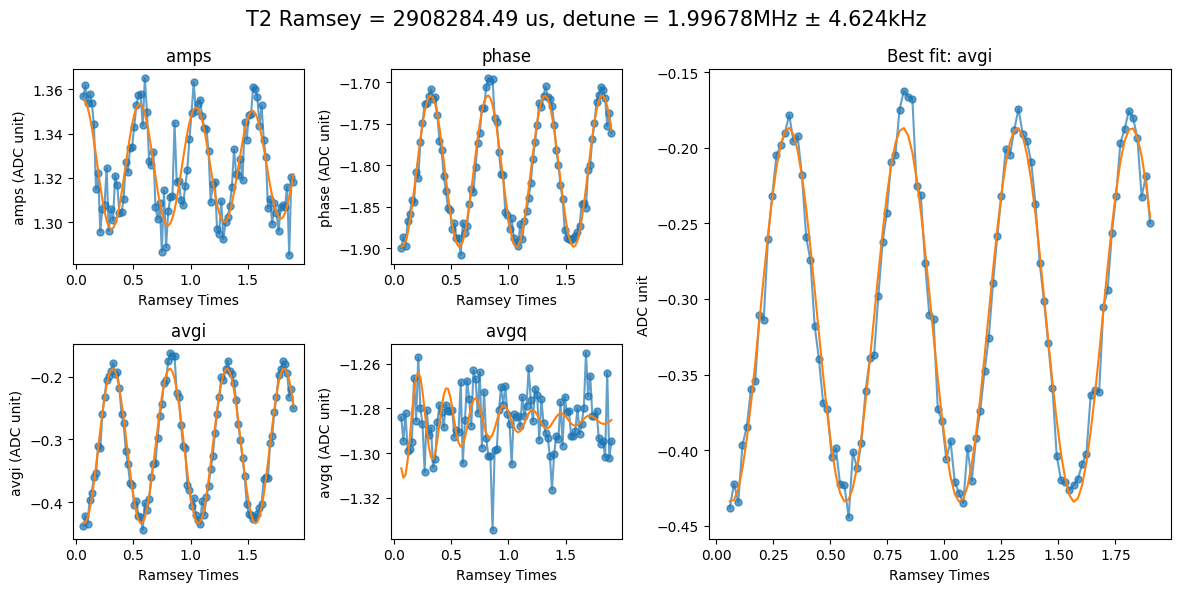

In [50]:
from qick_workspace.newscrip.s006_Ramsey_ge import Ramsey

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2 # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq",2),
        # ("pulse_type", "drag"),
    ]
)

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(20)

In [34]:
config_all.update("qb_freq_ge", t2r.correct_detune(), qubit)

Detune < 5kHz


In [243]:
t2r.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0330\s006_Ramsey_ge_Q2_001


In [96]:
from qick_workspace.newscrip.s010_cryoscope import Cryoscope, CryoscopeProgram

TAU_START = 0.01  # us
TAU_STOP = 0.2  # us


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", 81),
        ("flux_length", QickSweep1D("tloop", TAU_START, TAU_STOP)),
        ("flux_gain", 0.1),
        ("flux_ch", 15),
        ("relax_delay", 20),
    ]
)

prog = CryoscopeProgram(
    soccfg, reps=100, final_delay=run_cfg["relax_delay"], cfg=run_cfg
)
result1 = prog.acquire(soc, rounds=30)


run_cfg["flux_gain"] = 0.5
prog = CryoscopeProgram(
    soccfg, reps=100, final_delay=run_cfg["relax_delay"], cfg=run_cfg
)
result2 = prog.acquire(soc, rounds=20)

run_cfg["flux_gain"] = 1
prog = CryoscopeProgram(
    soccfg, reps=100, final_delay=run_cfg["relax_delay"], cfg=run_cfg
)
result3 = prog.acquire(soc, rounds=20)


# result = Cryoscope.run_xy(soc, soccfg, run_cfg, py_avg=50)
flux_len = prog.get_pulse_param("flux_pulse", "length", as_array=True)

Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_26448\3873301117.py", line 1, in <module>
    from qick_workspace.newscrip.s010_cryoscope import Cryoscope, CryoscopeProgram
ModuleNotFoundError: No module named 'qick_workspace.newscrip.s010_cryoscope'


c:\Users\QEL\anaconda3\envs\qick2env\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\QEL\anaconda3\envs\qick2env\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Detuning')

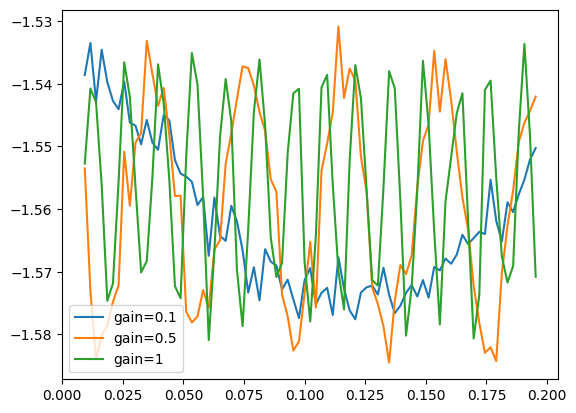

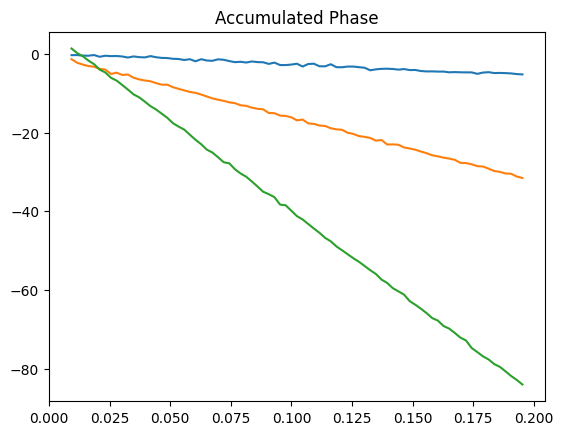

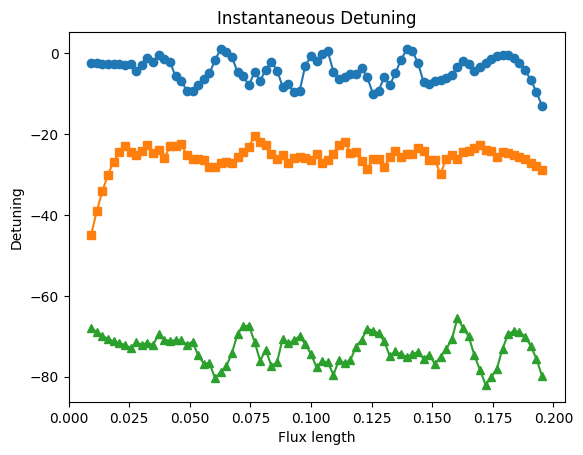

In [ ]:
X1 = result1[0][0].dot([1, 1j])
Y1 = result1[0][1].dot([1, 1j])
X2 = result2[0][0].dot([1, 1j])
Y2 = result2[0][1].dot([1, 1j])
X3 = result3[0][0].dot([1, 1j])
Y3 = result3[0][1].dot([1, 1j])

plt.plot(flux_len, X1, label="gain=0.1")
plt.plot(flux_len, X2, label="gain=0.5")
plt.plot(flux_len, X3, label="gain=1")
plt.legend()

X_centered1 = X1 - np.mean(X1)
Y_centered1 = Y1 - np.mean(Y1)
R1 = np.sqrt(X_centered1**2 + Y_centered1**2)
R1[R1 < 1e-6] = 1e-6
X_norm1 = X_centered1 / R1
Y_norm1 = Y_centered1 / R1
S1 = X_norm1 + 1j * Y_norm1
phase1 = np.unwrap(np.angle(S1))

X_centered2 = X2 - np.mean(X2)
Y_centered2 = Y2 - np.mean(Y2)
R2 = np.sqrt(X_centered2**2 + Y_centered2**2)
R2[R2 < 1e-6] = 1e-6
X_norm2 = X_centered2 / R2
Y_norm2 = Y_centered2 / R2
S2 = X_norm2 + 1j * Y_norm2
phase2 = np.unwrap(np.angle(S2))

X_centered3 = X3 - np.mean(X3)
Y_centered3 = Y3 - np.mean(Y3)
R3 = np.sqrt(X_centered3**2 + Y_centered3**2)
R3[R3 < 1e-6] = 1e-6
X_norm3 = X_centered3 / R3
Y_norm3 = Y_centered3 / R3
S3 = X_norm3 + 1j * Y_norm3
phase3 = np.unwrap(np.angle(S3))


plt.figure()
plt.plot(flux_len, phase1, label="gain=0.1")
plt.plot(flux_len, phase2, label="gain=0.5")
plt.plot(flux_len, phase3, label="gain=1")
plt.title("Accumulated Phase")


from scipy.signal import savgol_filter

dt = flux_len[1] - flux_len[0]

window_length = 13
polyorder = 3

phase_deriv1 = savgol_filter(phase1, window_length, polyorder, deriv=1)
freq1 = phase_deriv1 / dt / (2 * np.pi)

phase_deriv2 = savgol_filter(phase2, window_length, polyorder, deriv=1)
freq2 = phase_deriv2 / dt / (2 * np.pi)

phase_deriv3 = savgol_filter(phase3, window_length, polyorder, deriv=1)
freq3 = phase_deriv3 / dt / (2 * np.pi)

plt.figure()
plt.plot(flux_len, freq1, label="gain=0.1", marker="o")
plt.plot(flux_len, freq2, label="gain=0.5", marker="s")
plt.plot(flux_len, freq3, label="gain=1", marker="^")
plt.title("Instantaneous Detuning")
plt.xlabel("Flux length")
plt.ylabel("Detuning")

  0%|          | 0/50 [00:00<?, ?it/s]

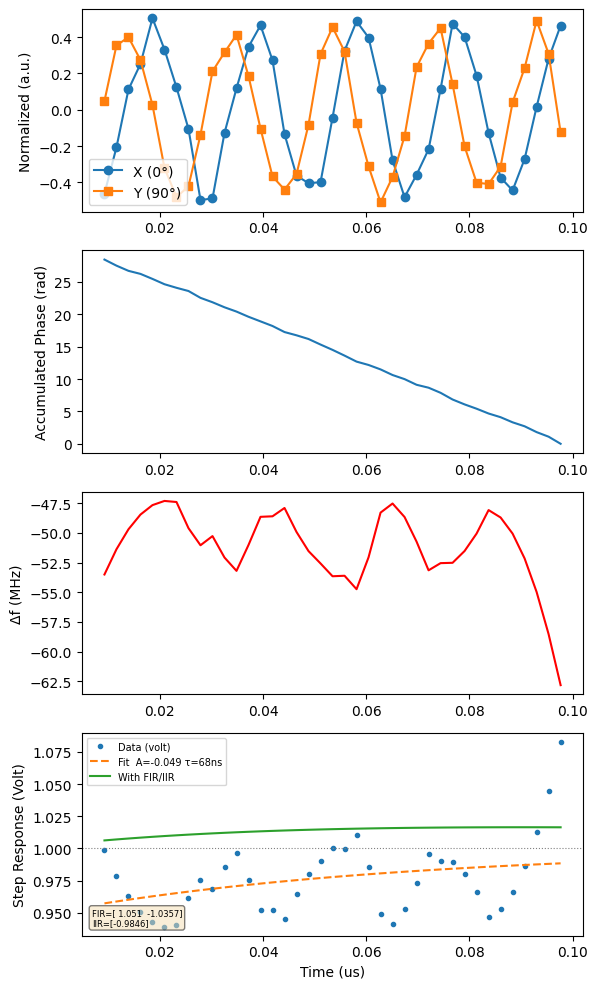

{'detuning': array([-53.50636094, -51.38147975, -49.69973682, -48.46113217,
        -47.66566577, -47.31333764, -47.40414778, -49.60710176,
        -51.04468609, -50.27397185, -52.0784764 , -53.19952236,
        -51.02046262, -48.65154615, -48.60735199, -47.90661776,
        -49.92728301, -51.53747939, -52.5764401 , -53.65401273,
        -53.61223423, -54.74421961, -52.05931648, -48.29677894,
        -47.53081   , -48.66790376, -50.73945588, -53.15395968,
        -52.55059904, -52.52131454, -51.52918315, -50.06135095,
        -48.08403684, -48.70759133, -50.06422933, -52.15395085,
        -54.97675589, -58.53264444, -62.82161651]),
 'step_response_freq': array([0.99787847, 0.95825003, 0.926886  , 0.90378638, 0.88895116,
        0.88238034, 0.88407392, 0.92515839, 0.95196893, 0.93759533,
        0.97124882, 0.99215601, 0.95151717, 0.90733755, 0.90651334,
        0.89344484, 0.93112968, 0.96115938, 0.98053571, 1.00063213,
        0.99985297, 1.02096418, 0.9708915 , 0.90072124, 0.88643613

In [ ]:
from qick_workspace.newscrip.s010_cryoscope import Cryoscope, CryoscopeProgram

TAU_START = 0.01  # us
TAU_STOP = 0.1  # us


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", 39),
        ("flux_length", QickSweep1D("tloop", TAU_START, TAU_STOP)),
        ("flux_gain", 0.8),
        ("flux_ch", 15),
        ("relax_delay", 20),
    ]
)

prog = Cryoscope(soc, soccfg, run_cfg)
prog.run_xy(soc, soccfg, run_cfg, py_avg=50)


Cryoscope PS Sweep: 100%|██████████| 100/100 [00:57<00:00,  1.75it/s]


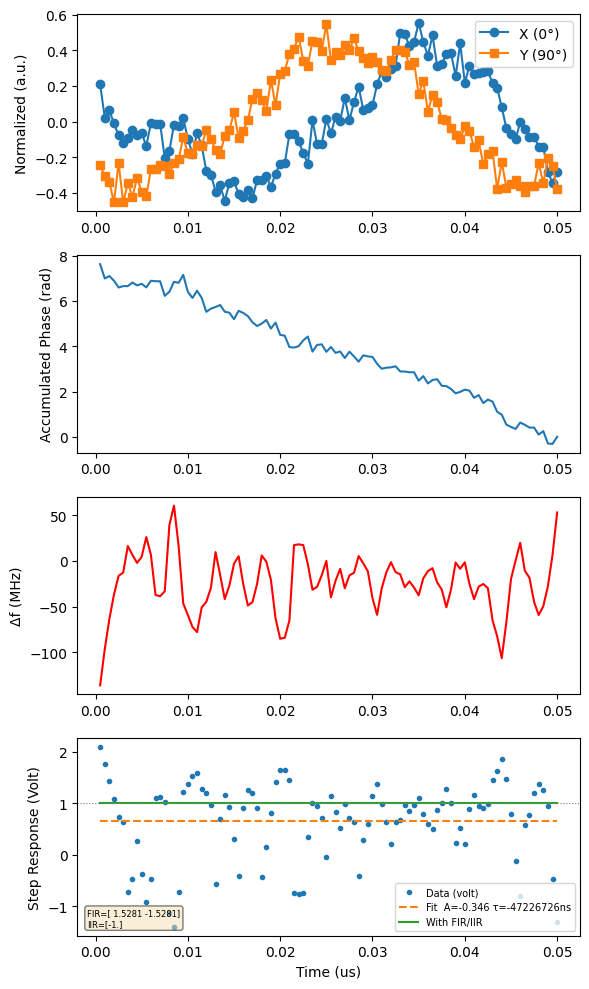

In [ ]:
from qick_workspace.newscrip.s010_cryoscope import Cryoscope


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("flux_gain", 1),
        ("flux_ch", 15),
        ("relax_delay", 30),
    ]
)
times_ps = np.linspace(0.0005, 0.05, 100)
results = Cryoscope.run_ps(soc, soccfg, run_cfg, py_avg=30, times_us=times_ps)


## Spin Echo ge

Experiment interrupted at 2 averages. Fit is based on partial data.


(array([ 5.92407227e-02,  8.35845455e-02,  2.22488101e+02,  4.48869978e+01,
        -6.21261518e-01]),
 array([1.35924878e-02, 1.24272053e-03, 1.40086433e+01, 1.52643338e+01,
        2.74481875e-03]))

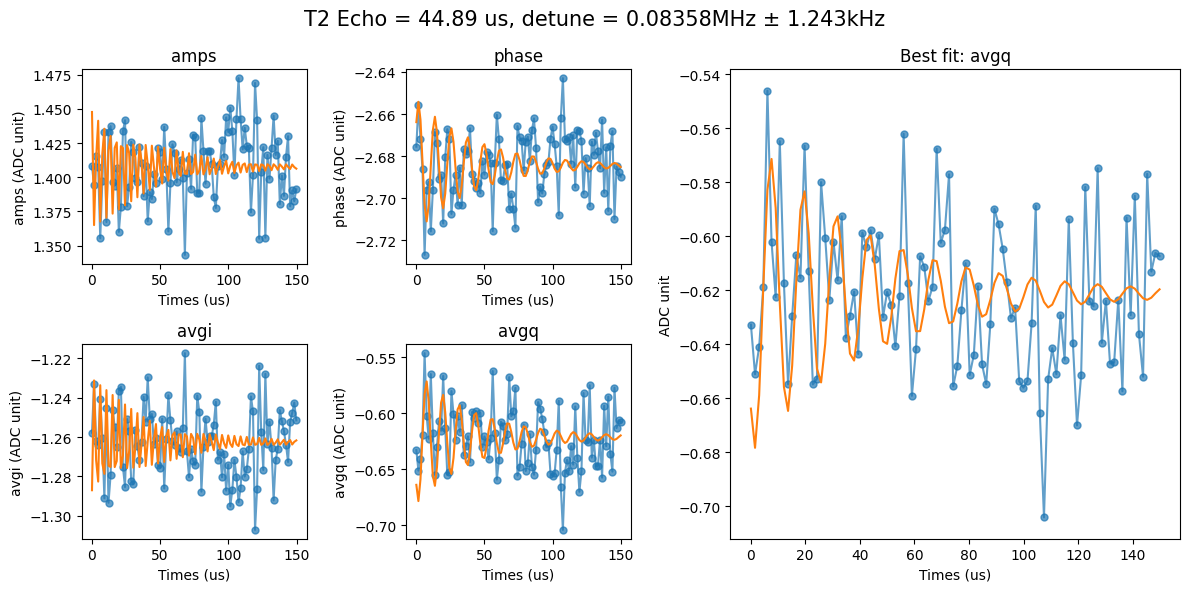

In [31]:
from qick_workspace.newscrip.s007_SpinEcho_ge import SpinEcho

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 150  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 0.05),
        # ("pulse_type", "drag")
    ]
)

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(100)

In [112]:
t2e.saveLabber(qubit, config_all=config_all, title="10mK")

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s007_SpinEcho_ge_Q1_10mK_002


## T1 ge

Experiment interrupted at 4 averages. Fit is based on partial data.


(array([ 2.34819028,  0.44562165, 43.84010192]),
 array([0.00295163, 0.01238389, 2.1143973 ]))

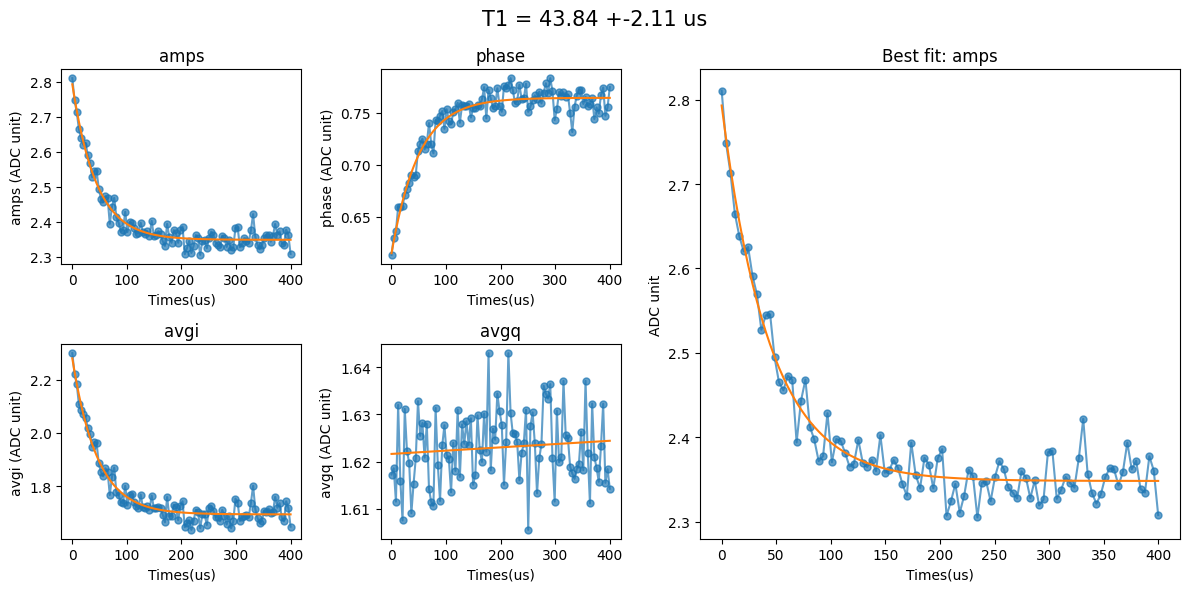

In [126]:
from qick_workspace.newscrip.s008_T1_ge import T1

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 400  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        # ('pulse_type', "drag"),
    ]
)

t1 = T1(soc, soccfg, run_cfg)
t1.run(50)

In [ ]:
t1.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s008_T1_ge_Q1_10mK_004


In [4]:
from qick_workspace.newscrip.s008_T1_ge_ff import T1FastFlux

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 10  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("relax_delay", 30),
        ### Flux Pulse ###
        ("steps_flux", 21),
        ("flux_length", 0.01 + QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("flux_gain", QickSweep1D("fluxloop", -1.0, 1.0)),
        ("flux_ch", 15),
    ]
)

t1 = T1FastFlux(soc, soccfg, run_cfg)
t1.run(30)

Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_12476\2585222871.py", line 1, in <module>
    from qick_workspace.newscrip.s008_T1_ge_ff import T1FastFlux
ModuleNotFoundError: No module named 'qick_workspace.newscrip.s008_T1_ge_ff'


In [ ]:
t1.saveLabber(qubit, config_all=config_all)

2026-03-25 14:24:33,689 - SR_Network:BlockingClient - Error: Socket operation timed out


Data saved to c:\Users\QEL\Desktop\SQC_soc\test\2026\03\Data_0325\s008_T1_ff_ge_Q1_001


## Single Shot

  0%|          | 0/5000 [00:00<?, ?it/s]

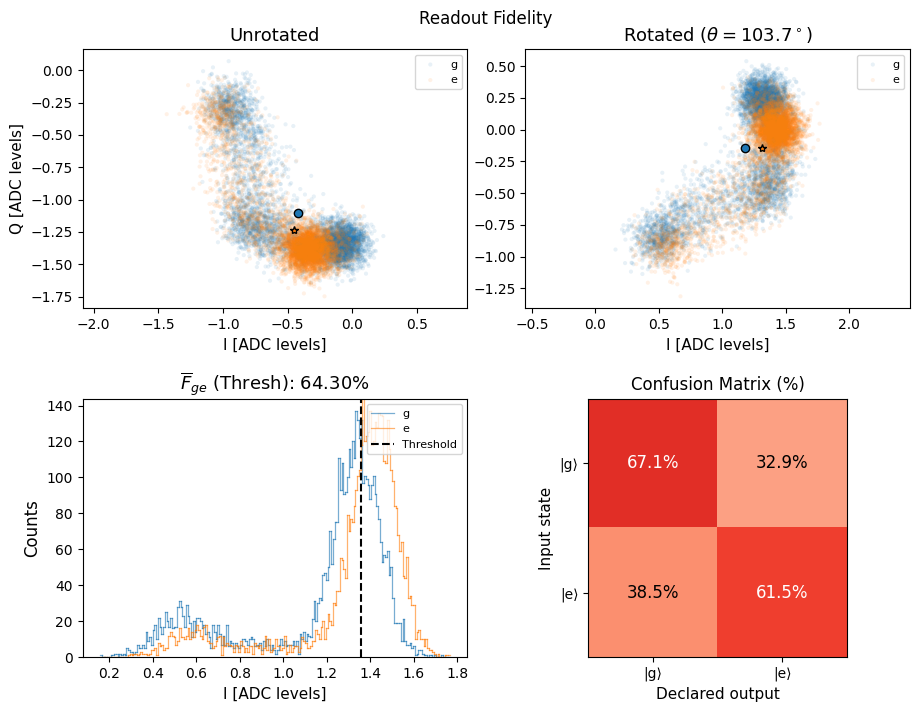

Theta: 103.71 deg
Threshold Fidelity: 64.300%
Confusion Matrix (%):
 [[67.06 32.94]
 [38.46 61.54]]
Current data file: D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s000_singleshot_ge_Q1_003


In [62]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)


run_cfg['pulse_type'] = "drag"
SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=False)
ssh.plot(fid_avg=True, verbose=True, fit=False)
ssh.saveLabber(qubit)

Length loop:   0%|          | 0/6 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/6 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/6 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/6 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/6 [00:00<?, ?it/s]

...

Freq loop:   0%|          | 0/6 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/6 [00:00<?, ?it/s]

Analyze max fidelity:   0%|          | 0/6 [00:00<?, ?it/s]


--- Grid Search Result ---
Max fidelity (on grid): 0.8915
At length=6.400 us, gain=0.08600 DAC, freq=6723.19624 MHz

--- Interpolated Result ---
Max fidelity (interpolated): 0.9448
At length=6.718 us, gain=0.08656 DAC, freq=6723.19624 MHz


  0%|          | 0/5000 [00:00<?, ?it/s]

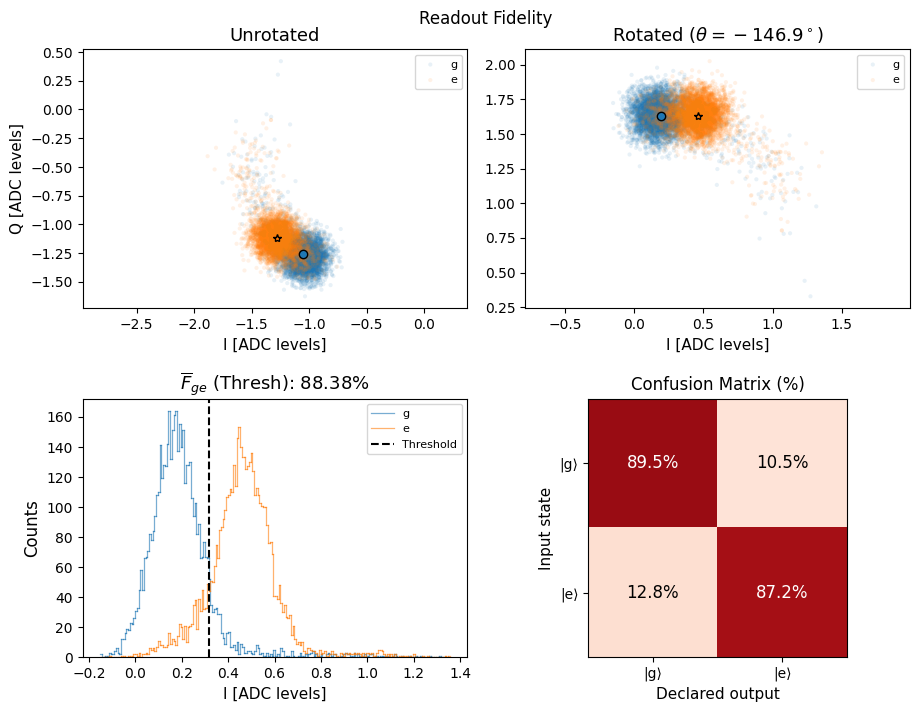

Theta: -146.93 deg
Threshold Fidelity: 88.380%
Confusion Matrix (%):
 [[89.54 10.46]
 [12.78 87.22]]


[[np.float64(0.8838)],
 [np.float64(0.3154188480094883)],
 np.float64(-146.92531196421893)]

In [ ]:
from qick_workspace.newscrip.s000_SingleShot_opt import SingleShot_ge_opt

run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"

freq_axis = np.linspace(run_cfg["res_freq_ge"] - 1, run_cfg["res_freq_ge"] + 8, 6)
gain_axis = np.linspace(0.03, 0.1, 6)
length_axis = np.linspace(4, 7, 6)
sweep_para = {"freq":freq_axis, "gain": gain_axis, "length": length_axis}


SHOT = 2000
ssh_opt = SingleShot_ge_opt(soc, soccfg, run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para)

### analyze and update config ###
length, gain, freq = ssh_opt.analyze()
config_all.update("ro_length", length, q_index=qubit)
config_all.update("res_gain_ge", gain, q_index=qubit)
config_all.update("res_freq_ge", freq, q_index=qubit)

### run single shot with optimized parameters ###
run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"
SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True, fit=False)
config_all.update('res_phase', ssh_result[2], q_index=qubit)

# EF State

## Resonator OneTone ef

Experiment interrupted at 3 averages. Fit is based on partial data.


c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': np.float64(6.8116),
 'Qi': -28546,
 'Ql': 1286,
 'absQc': 1231,
 'κ(MHz)': np.float64(5.3)}


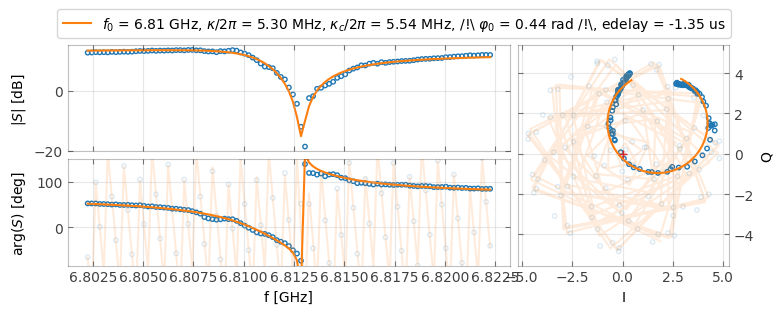

In [ ]:
from qick_workspace.newscrip.s009_res_spec_ef import ResonatorSpec_ef

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101

config_all.update("res.res_gain_ge", 0.1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),

    ]
)

onetone_ef = ResonatorSpec_ef(soc, soccfg, run_cfg)
fres = onetone_ef.run(py_avg=20, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone_ef.saveLabber(qubit, yoko_value=yoko_value)

## Qubit Spectrum ef

Experiment interrupted at 5 averages. Fit is based on partial data.


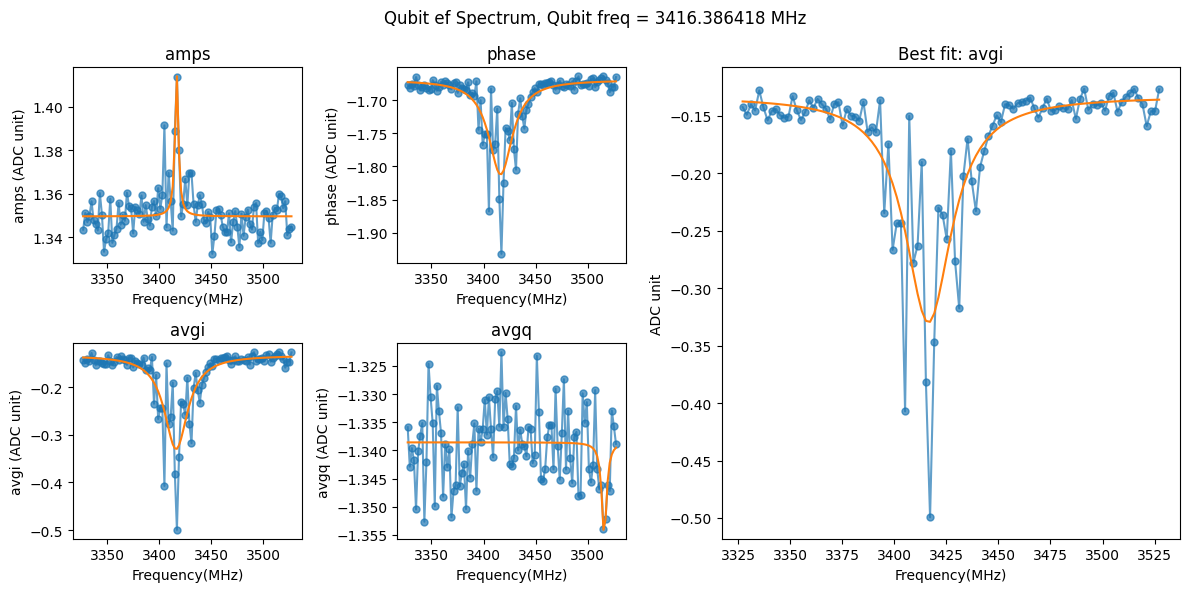

In [53]:
from qick_workspace.newscrip.s010_qubit_spec_ef import QubitSpec_ef

center = config_all.get_qubit(qubit)["qb_freq_ge"] - 200
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 101
config_all.update("qb_ch_ef", 0, q_index=qubit)
config_all.update("nqz_qb_ef", 2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ef", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_gain_ef", 0.3),
        ("qb_flat_top_length_ef", 2),
        ("ge_ref", True),
    ]
)

spectrum_ef = QubitSpec_ef(soc, soccfg, run_cfg)
f_ef = spectrum_ef.run(10)
config_all.update("qb_freq_ef", f_ef, q_index=qubit)
config_all.update("qb_mixer_ef", f_ef, q_index=qubit)
# spectrum_ef.saveLabber(qubit, yoko_value=yoko_value)

In [120]:
spectrum_ef.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s010_qubit_spec_ef_Q1_001


## Power Rabi ef

Experiment interrupted at 4 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s011_power_rabi_ef_Q1_008


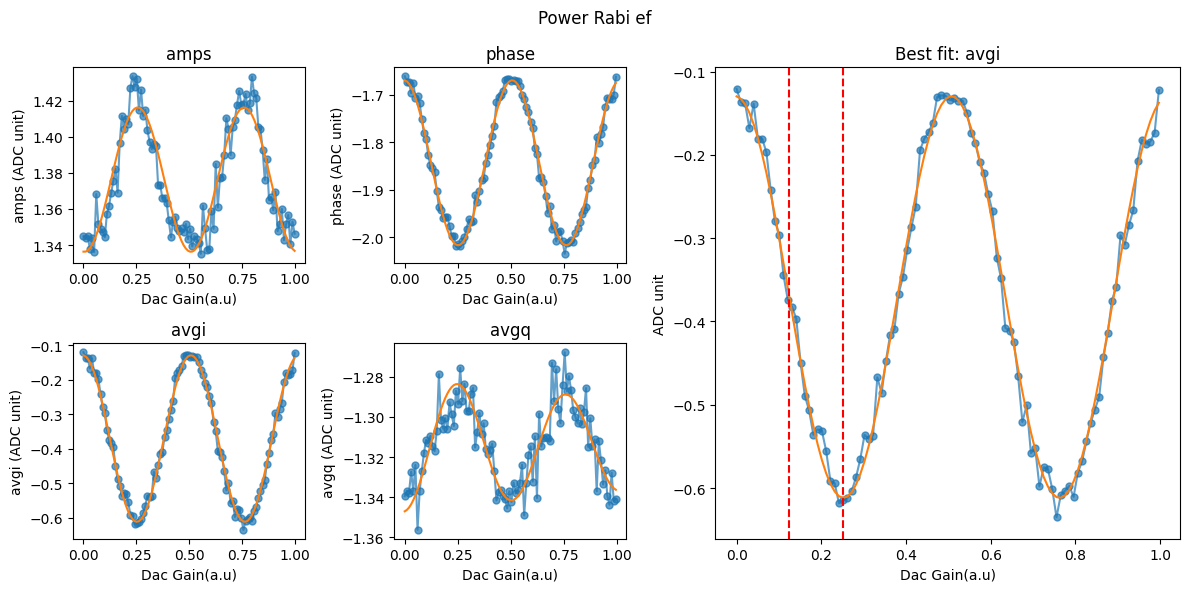

In [54]:
from qick_workspace.newscrip.s011_power_rabi_ef import PowerRabi_ef

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
    ]
)

prabi_ef = PowerRabi_ef(soc, soccfg, run_cfg)
pi_gain_ef, pi2_gain_ef = prabi_ef.run(50)
config_all.update("pi_gain_ef", pi_gain_ef, q_index=qubit)
config_all.update("pi2_gain_ef", pi2_gain_ef, q_index=qubit)
prabi_ef.saveLabber(qubit, config_all=config_all)

[Temp] A_meas=0.0278  A_ref=0.0342  ratio=1.2308
[Temp] Estimated temperature: 838.25 mK


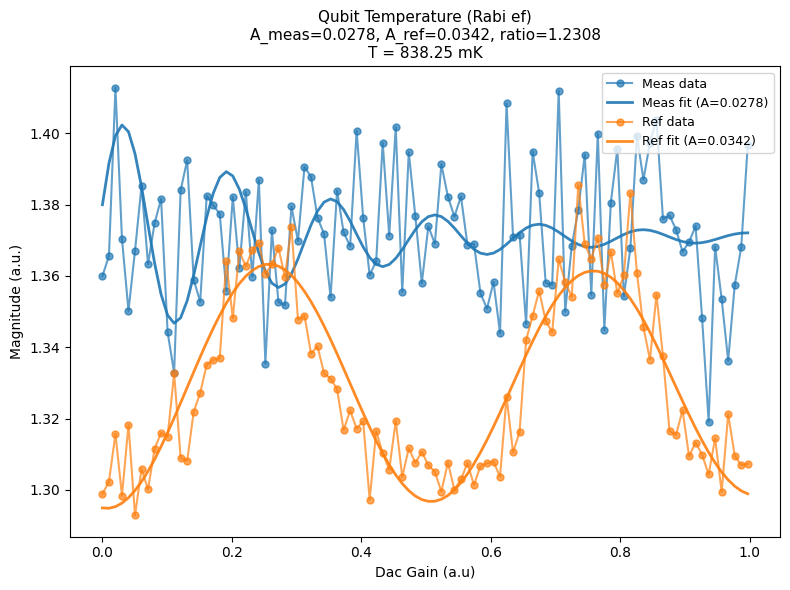

np.float64(0.8382483250165554)

In [55]:
from qick_workspace.newscrip.s013_qubit_temp import QubitTemperatureEf

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)
config_all.update("relax_delay", 100, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
        ("ro_length", 2),
    ]
)
rabi_temp = QubitTemperatureEf(soc, soccfg, run_cfg)
rabi_temp.run(5)

In [123]:
rabi_temp.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s013b_qubit_temp_ef_Q1_002


## Ramsey ef

Experiment interrupted at 4 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s012_Ramsey_ef_Q1_007


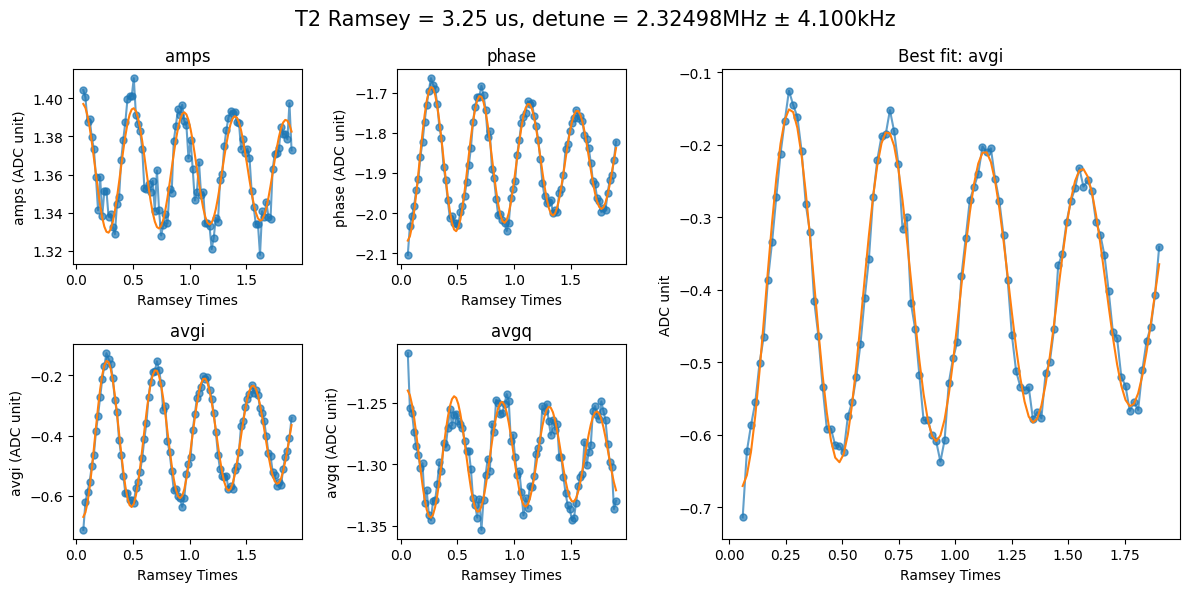

In [56]:
from qick_workspace.newscrip.s012_Ramsey_ef import Ramsey_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 2),
        ("ge_ref", True),

    ]
)

t2r_ef = Ramsey_ef(soc, soccfg, run_cfg)
t2r_ef.run(100)
t2r_ef.saveLabber(qubit, config_all=config_all)

In [57]:
config_all.update("qb_freq_ef", t2r_ef.correct_detune(), qubit)

over detune 0.32498MHz


## T1 ef

Experiment interrupted at 4 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s013_T1_ef_Q3_001


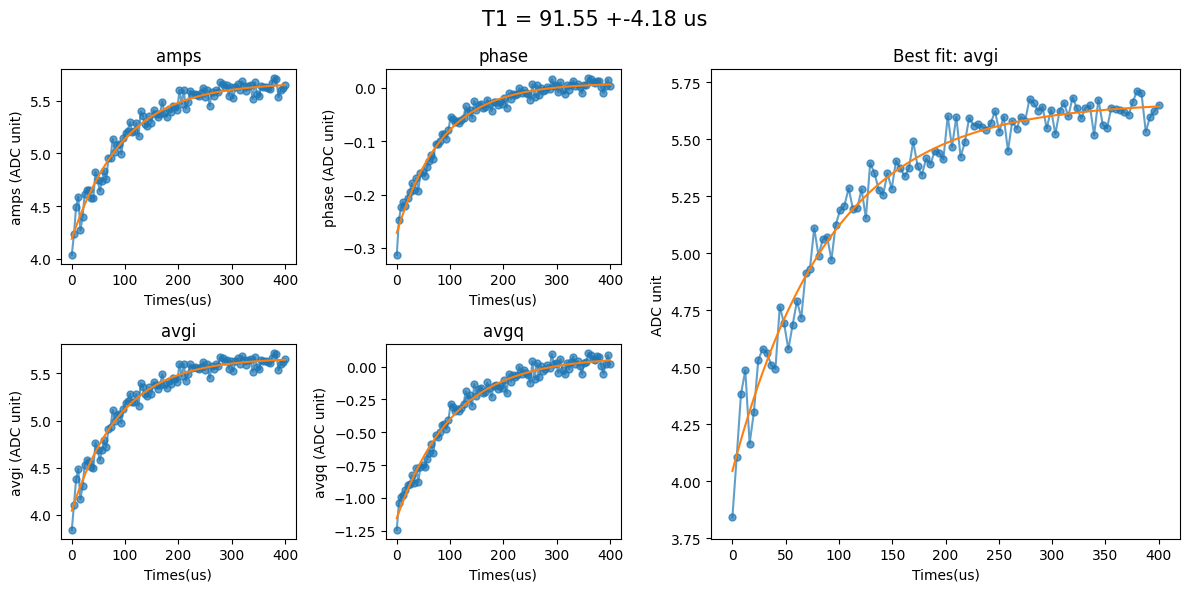

In [76]:
from qick_workspace.newscrip.s013_T1_ef import T1_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 400  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),

    ]
)

t1_ef = T1_ef(soc, soccfg, run_cfg)
t1_ef.run(50)
t1_ef.saveLabber(qubit, config_all=config_all)

## Single Shot gef

  0%|          | 0/5000 [00:00<?, ?it/s]

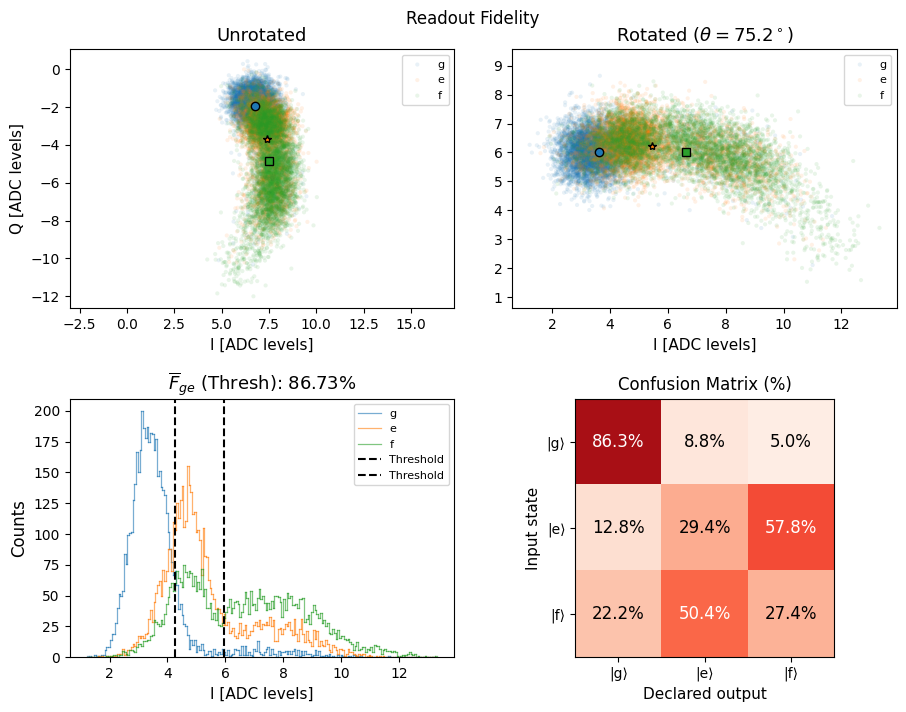

Theta: 75.19 deg
Threshold Fidelity: 86.730%
Confusion Matrix (%):
 [[86.26  8.76  4.98]
 [12.8  29.38 57.82]
 [22.18 50.4  27.42]]


[[np.float64(0.8673)],
 [np.float64(4.24714592991733), np.float64(5.939404465527091)],
 np.float64(75.19469870369264)]

In [124]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)


SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True, fit=False)

# AllXY

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

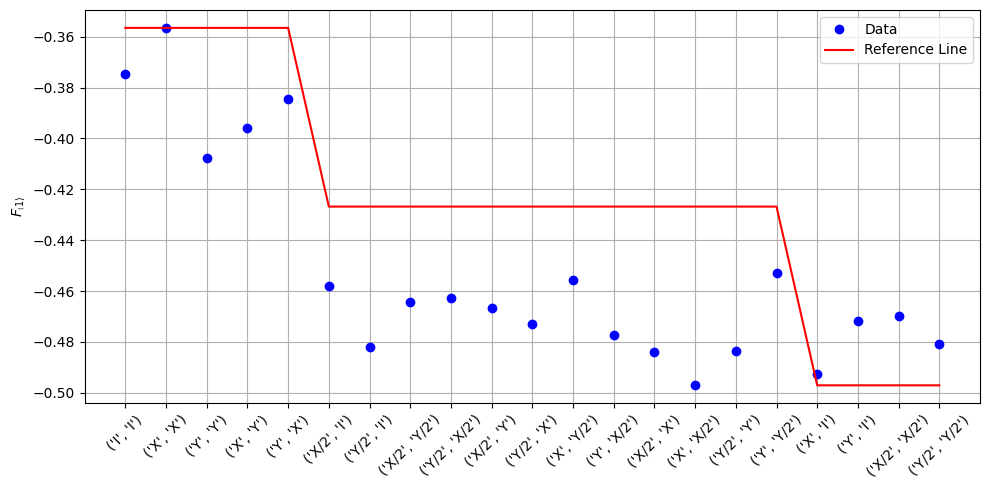

In [60]:
from qick_workspace.newscrip.s014_AllXY import AllXY

run_cfg = config_all.get_qubit(qubit)

run_cfg.update([
    # ("pulse_type", "drag"),
])
allxy = AllXY(soc, soccfg, run_cfg)
allxy.run(10)
allxy.plot()

### Drag allxy

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

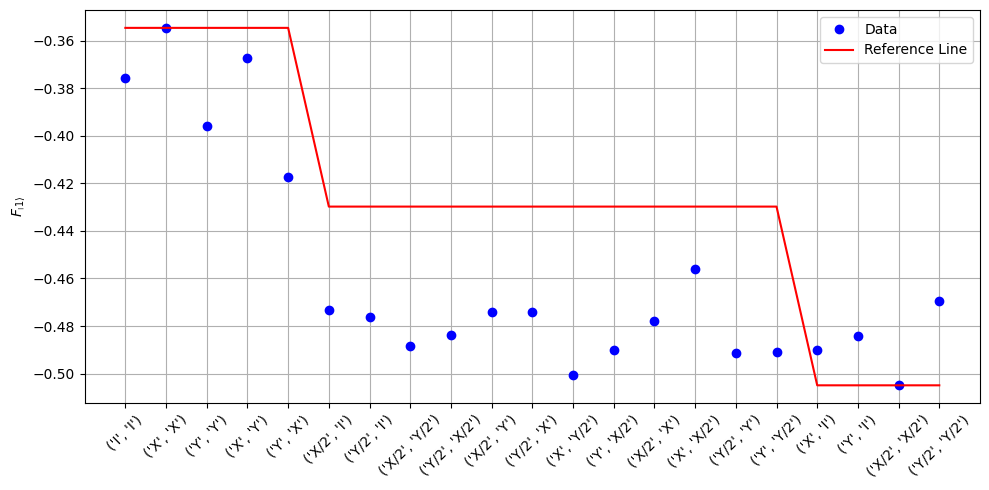

In [59]:
from qick_workspace.newscrip.s014_AllXY import AllXY
# config_all.update("relax_delay", 400, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("pulse_type", "drag"),
])
allxy = AllXY(soc, soccfg, run_cfg)
allxy.run(10)
allxy.plot()

## State tomography 

Calibrating |0⟩ state...
Calibrating |1⟩ state...
IQ Ground: (0.13794304312449146-1.2647990235964197j), IQ Excited: (-0.059762408462164365-1.2947615947925142j)


Tomography (x180):   0%|          | 0/3 [00:00<?, ?it/s]


<X>=0.0643, <Y>=0.0510, <Z>=-0.9558
Purity: 0.96018


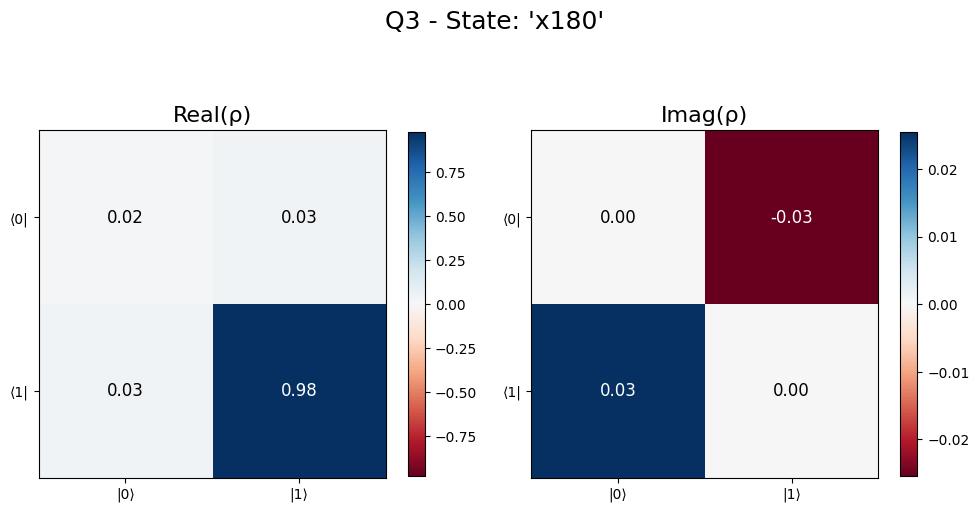

c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\newscrip\s016_state_tomography.py:198: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


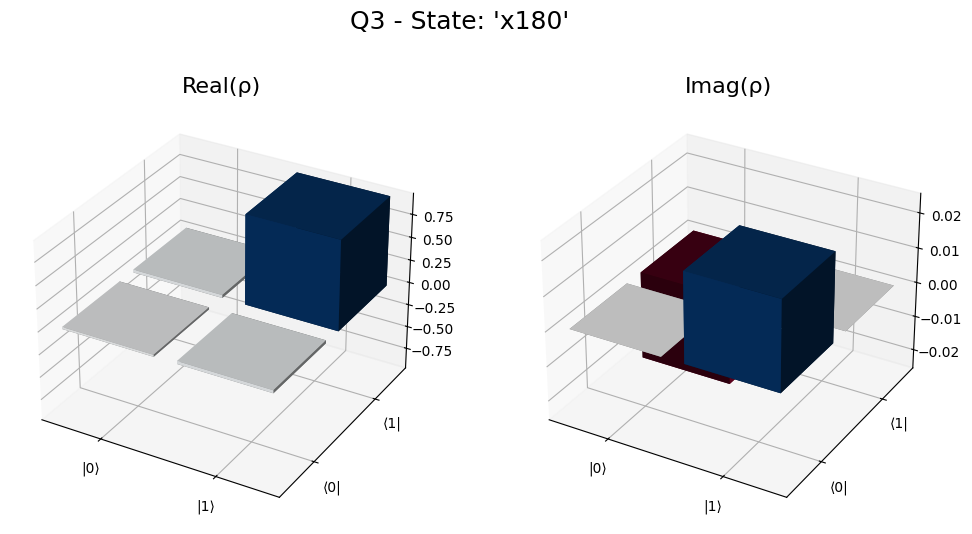

(<Figure size 1200x600 with 2 Axes>, None)

In [36]:
from qick_workspace.newscrip.s016_state_tomography import Tomography

pyavg = 5

run_cfg = config_all.get_qubit(qubit)

tomo = Tomography(soc, soccfg, run_cfg)

tomo.run(py_avg=pyavg, prep_pulse_name="x180")

tomo.plot(plot_type="2d", qb_idx=3)
tomo.plot(plot_type="3d", qb_idx=3)

# Randomized Benchmarking


=== Standard RB (Reference) ===


Standard RB:   0%|          | 0/24 [00:00<?, ?it/s]

Samples:   0%|          | 0/100 [00:00<?, ?it/s]

Samples:   0%|          | 0/100 [00:00<?, ?it/s]

Samples:   0%|          | 0/100 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/100 [00:00<?, ?it/s]

Samples:   0%|          | 0/100 [00:00<?, ?it/s]

Samples:   0%|          | 0/100 [00:00<?, ?it/s]

Samples:   0%|          | 0/100 [00:00<?, ?it/s]

[fitrb] p=0.999769  a=0.3727  b=1.1717
[fitrb] σ(p)=3.81e-03  σ(a)=5.74e+00  σ(b)=5.75e+00
  p        = 99.9769 ± 0.3807 %
  F_gate   = 99.9906 ± 0.3345 %
  EPC      = 0.0094 ± 0.3345 %


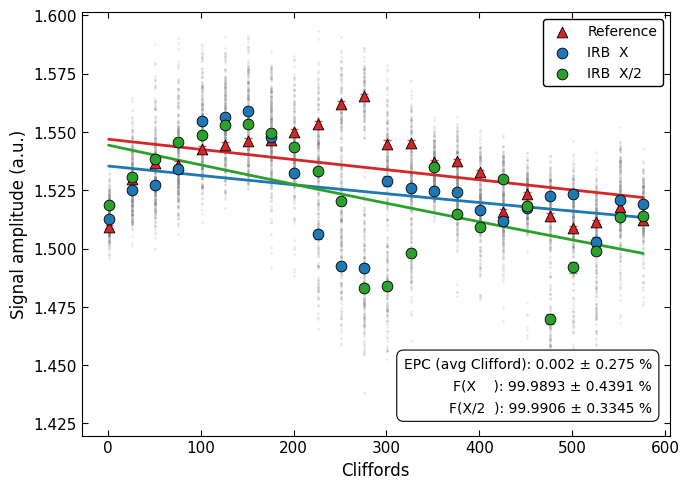

RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0407\s015_RB_Q1_ref_014
RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0407\s015_RB_X_Q1_010
RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0407\s015_RB_halfX_Q1_011
  AutoRB Summary
  Reference EPC : 0.0022 ± 0.2750 %
  p (decay)     : 99.9956 ± 0.5501 %

  Gate fidelities:
    X       F = 99.9893 ± 0.4391 %  (EPC = 0.0107 %)
    X/2     F = 99.9906 ± 0.3345 %  (EPC = 0.0094 %)


In [164]:
from qick_workspace.newscrip.s015_Auto_RB import AutoRB

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

auto = AutoRB(soc, soccfg, run_cfg)
interleaved = ["X", "X/2"]
auto.run(
    py_avg=10,
    max_circuit_depth=600,
    delta_clifford=25,
    number_sample=100,
    interleaved_gates=interleaved,
)
auto.plot()
auto.saveLabber(qubit, config_all=config_all)
print(auto.summary())


--- Running Standard RB (Ref) ---


Standard RB:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

[fitrb] p=0.976024  a=-0.1215  b=2.6340
[fitrb] σ(p)=4.34e-02  σ(a)=9.28e-02  σ(b)=3.61e-02

--- Ref ---
  p   = 97.602398 ± 4.339048 %
  EPC = 1.198801 ± 2.169524 %
RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s015_RB_Q1_ref_020


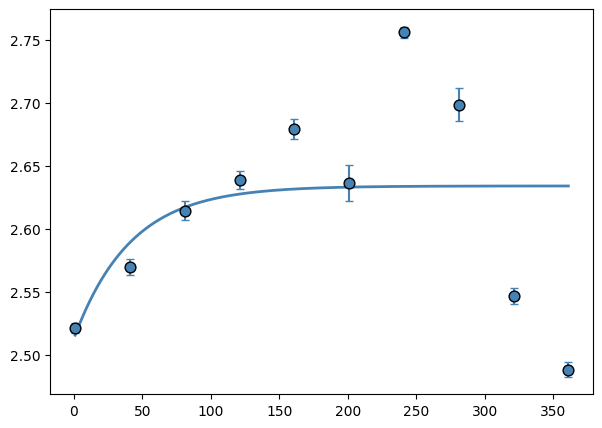

In [17]:
from qick_workspace.newscrip.s015_Single_qubit_RB import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"


py_avg = 10
max_circuit_depth = 400
delta_clifford = 40
number_sample = 50

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(soc, soccfg, run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)
rb_exp_ref.saveLabber(qubit, config_all=config_all)

In [18]:
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
# interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]
interleaved_gates_to_test = ["X/2"]


for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(soc, soccfg, run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)
    rb_exp_irb.saveLabber(qubit, config_all=config_all)


--- Running Interleaved RB (X/2) ---


IRB (X/2):   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s015_RB_halfX_Q1_012


[fitrb] p=0.999977  a=1.0000  b=0.5372
[fitrb] σ(p)=1.06e-02  σ(a)=4.64e+02  σ(b)=4.64e+02

--- IRB ---
  p   = 99.997739 ± 1.056916 %
  EPC = 0.001131 ± 0.528458 %


(np.float64(1.130610394439735e-05),
 0.005284578590617893,
 np.float64(0.9999773877921112),
 0.010569157181235786,
 array([[ 1.11707084e-04,  4.90386323e+00, -4.90394555e+00],
        [ 4.90386323e+00,  2.15277075e+05, -2.15280682e+05],
        [-4.90394555e+00, -2.15280682e+05,  2.15284290e+05]]))

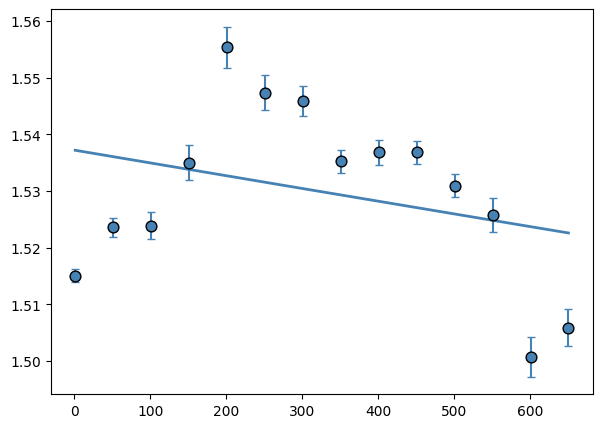

In [157]:
rb_exp_irb.plot(label="IRB")

[fitrb] p=0.999476  a=0.3988  b=-0.0291
[fitrb] σ(p)=1.92e-03  σ(a)=1.28e+00  σ(b)=1.29e+00

--- Reference ---
  p   = 99.947605 ± 0.191601 %
  EPC = 0.026198 ± 0.095801 %
[fitrb] p=0.992353  a=0.0577  b=0.3075
[fitrb] σ(p)=4.32e-03  σ(a)=1.21e-02  σ(b)=8.91e-03

--- IRB  X ---
  p   = 99.235295 ± 0.431679 %
  EPC = 0.382353 ± 0.215840 %


Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_21132\1880840758.py", line 36, in <module>
    fid_err  = rb_gate_fidelity_err(
NameError: name 'rb_gate_fidelity_err' is not defined


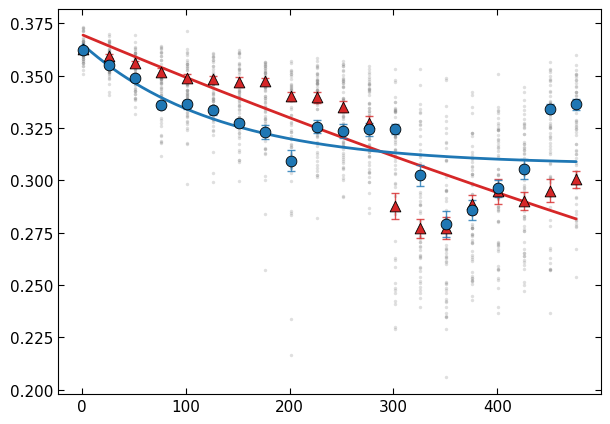

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from qick_workspace.tools.fitting import rb_gate_fidelity

REF_COLOR  = "tab:red"
IRB_COLORS = ["tab:blue", "tab:green", "tab:orange", "tab:purple", "tab:cyan"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.8)
ax.tick_params(colors="black", labelsize=11, direction="in",
               top=True, right=True, length=4)
ax.grid(False)

# ── Reference RB ─────────────────────────────────────────────────────────────
epc_ref, epc_err_ref, p_ref, p_err_ref, pCov_ref = rb_exp_ref.plot(
    label="Reference", color=REF_COLOR,
    marker="^", ax=ax, show_individual=True,
)

# ── Interleaved RB ────────────────────────────────────────────────────────────
gate_results = {}
for i, (rb_exp_irb, gate) in enumerate(
    zip(all_rb_results[1:], interleaved_gates_to_test)
):
    c = IRB_COLORS[i % len(IRB_COLORS)]
    epc_irb, epc_err_irb, p_irb, p_err_irb, pCov_irb = rb_exp_irb.plot(
        label=f"IRB  {gate}", color=c,
        marker="o", ax=ax, show_individual=True,
    )
    fidelity = rb_gate_fidelity(p_ref, p_irb, d=2)
    fid_err  = rb_gate_fidelity_err(
        p_ref, p_irb,
        cov_p_rb=pCov_ref[0, 0], cov_p_irb=pCov_irb[0, 0], d=2,
    )
    gate_results[gate] = (fidelity, fid_err, c)

# ── Annotation box ────────────────────────────────────────────────────────────
ann_lines = [f"EPC:  {epc_ref*100:.3f} ± {epc_err_ref*100:.3f} %"]
for gate, (fid, err, _) in gate_results.items():
    ann_lines.append(f"F({gate}): {fid*100:.4f} ± {err*100:.4f} %")
ann_text = "\n".join(ann_lines)

ax.text(0.97, 0.05, ann_text,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=10, color="black",
        linespacing=1.7,
        bbox=dict(boxstyle="round,pad=0.5",
                  facecolor="white",
                  edgecolor="black",
                  linewidth=0.8))

# ── Labels & legend ───────────────────────────────────────────────────────────
ax.set_xlabel("Cliffords", fontsize=12)
ax.set_ylabel("Signal amplitude (a.u.)", fontsize=12)
ax.legend(fontsize=10, frameon=True,
          framealpha=1.0, edgecolor="black",
          loc="upper left")

fig.tight_layout()
plt.show()

# ── Console summary ───────────────────────────────────────────────────────────
print("\n=== Gate Fidelities ===")
for gate, (fid, err, _) in gate_results.items():
    print(f"  {gate:6s}  F = {fid*100:.4f} ± {err*100:.4f} %")

# Nodrag

In [ ]:
from qick_workspace.newscrip.s015_Single_qubit_RB import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"
run_cfg['relax_delay'] = 500
run_cfg['pi2_gain_ge']= 0.118189713318076


py_avg = 15
max_circuit_depth = 700
delta_clifford = 25
number_sample = 100

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(soc, soccfg, run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
    interleaved_gate=None,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)
rb_exp_ref.saveLabber(qubit, config_all=config_all)
## Interleaved RB
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]
# interleaved_gates_to_test = ["X", "X/2"]


for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(soc, soccfg, run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)
    rb_exp_irb.saveLabber(qubit, config_all=config_all)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from qick_workspace.tools.fitting import rb_gate_fidelity

REF_COLOR  = "tab:red"
IRB_COLORS = ["tab:blue", "tab:green", "tab:orange", "tab:purple", "tab:cyan"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.8)
ax.tick_params(colors="black", labelsize=11, direction="in",
               top=True, right=True, length=4)
ax.grid(False)

# ── Reference RB ─────────────────────────────────────────────────────────────
epc_ref, epc_err_ref, p_ref, p_err_ref, pCov_ref = rb_exp_ref.plot(
    label="Reference", color=REF_COLOR,
    marker="^", ax=ax, show_individual=True,
)

# ── Interleaved RB ────────────────────────────────────────────────────────────
gate_results = {}
for i, (rb_exp_irb, gate) in enumerate(
    zip(all_rb_results[1:], interleaved_gates_to_test)
):
    c = IRB_COLORS[i % len(IRB_COLORS)]
    epc_irb, epc_err_irb, p_irb, p_err_irb, pCov_irb = rb_exp_irb.plot(
        label=f"IRB  {gate}", color=c,
        marker="o", ax=ax, show_individual=True,
    )
    fidelity = rb_gate_fidelity(p_ref, p_irb, d=2)
    fid_err  = rb_gate_fidelity_err(
        p_ref, p_irb,
        cov_p_rb=pCov_ref[0, 0], cov_p_irb=pCov_irb[0, 0], d=2,
    )
    gate_results[gate] = (fidelity, fid_err, c)

# ── Annotation box ────────────────────────────────────────────────────────────
ann_lines = [f"EPC:  {epc_ref*100:.3f} ± {epc_err_ref*100:.3f} %"]
for gate, (fid, err, _) in gate_results.items():
    ann_lines.append(f"F({gate}): {fid*100:.4f} ± {err*100:.4f} %")
ann_text = "\n".join(ann_lines)

ax.text(0.97, 0.05, ann_text,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=10, color="black",
        linespacing=1.7,
        bbox=dict(boxstyle="round,pad=0.5",
                  facecolor="white",
                  edgecolor="black",
                  linewidth=0.8))

# ── Labels & legend ───────────────────────────────────────────────────────────
ax.set_xlabel("Cliffords", fontsize=12)
ax.set_ylabel("Signal amplitude (a.u.)", fontsize=12)
ax.legend(fontsize=10, frameon=True,
          framealpha=1.0, edgecolor="black",
          loc="upper left")

fig.tight_layout()
plt.show()

# ── Console summary ───────────────────────────────────────────────────────────
print("\n=== Gate Fidelities ===")
for gate, (fid, err, _) in gate_results.items():
    print(f"  {gate:6s}  F = {fid*100:.4f} ± {err*100:.4f} %")

# Drag


[DRAG Sum] Optimal α = 0.490714)


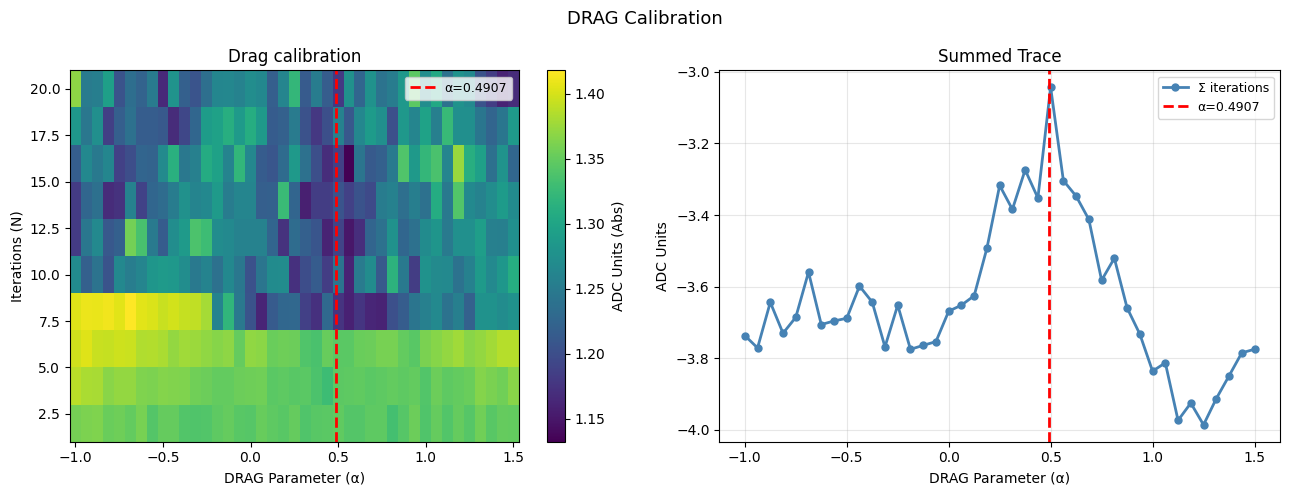

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s005a_drag_ge_Q1_012


In [58]:
from qick_workspace.newscrip.s005a_drag import DragCalibration

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        # Alpha
        ("alpha_start", -1),
        ("alpha_stop", 1.5),
        ("alpha_steps", 41), 
        # Iterationi
        ("iter_start", 2),
        ("iter_stop", 20),
        ("iter_step", 2),
    ]
)

drag_cal = DragCalibration(soc, soccfg, run_cfg)
fit_results = drag_cal.run(py_avg=5)


config_all.update("drag_alpha", fit_results['optimal_alpha'], q_index=qubit)

drag_cal.saveLabber(qubit, config_all=config_all)

In [45]:
import numpy as np
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Union
import json

# ---------------------------------------------------------------------------
# SU(2) matrix arithmetic (complex represented as (re, im) tuples)
# ---------------------------------------------------------------------------

def _c(re: float, im: float = 0.0) -> Tuple[float, float]:
    return (re, im)

def _cmul(a, b):
    return (a[0] * b[0] - a[1] * b[1], a[0] * b[1] + a[1] * b[0])

def _cadd(a, b):
    return (a[0] + b[0], a[1] + b[1])

def _cabs(a):
    return np.sqrt(a[0] ** 2 + a[1] ** 2)

Mat2 = List[List[Tuple[float, float]]]  # 2x2 complex matrix

def mat_mul(A: Mat2, B: Mat2) -> Mat2:
    """2x2 complex matrix multiply."""
    n = 2
    C = [[_c(0), _c(0)], [_c(0), _c(0)]]
    for i in range(n):
        for j in range(n):
            s = _c(0)
            for k in range(n):
                s = _cadd(s, _cmul(A[i][k], B[k][j]))
            C[i][j] = s
    return C

_I2: Mat2 = [[_c(1), _c(0)], [_c(0), _c(1)]]

def mat_normalize(M: Mat2) -> Mat2:
    """Remove global phase so the largest-magnitude element is real positive."""
    flat = [M[i][j] for i in range(2) for j in range(2)]
    best = max(flat, key=_cabs)
    mag = _cabs(best)
    if mag < 1e-9:
        return M
    phase_conj = (best[0] / mag, -best[1] / mag)
    return [[_cmul(M[i][j], phase_conj) for j in range(2)] for i in range(2)]

def mat_eq(A: Mat2, B: Mat2, tol: float = 0.05) -> bool:
    """Check equality up to global phase."""
    A = mat_normalize(A)
    B = mat_normalize(B)
    for i in range(2):
        for j in range(2):
            if abs(A[i][j][0] - B[i][j][0]) > tol:
                return False
            if abs(A[i][j][1] - B[i][j][1]) > tol:
                return False
    return True

def seq_to_mat(pulse_seq: List[str], prim: dict) -> Mat2:
    """Compose a list of primitive gate names into a single SU(2) matrix."""
    M = [row[:] for row in _I2]
    for p in pulse_seq:
        M = mat_mul(prim[p], M)
    return M

# ---------------------------------------------------------------------------
# Primitive gate matrices
# ---------------------------------------------------------------------------

s = 1.0 / np.sqrt(2)

PRIMITIVE_MATS: dict = {
    "I": [[_c(1), _c(0)], [_c(0), _c(1)]],
    "X": [[_c(0), _c(1)], [_c(1), _c(0)]],
    "Y": [[_c(0), _c(0, -1)], [_c(0, 1), _c(0)]],
    "Z": [[_c(1), _c(0)], [_c(0), _c(-1)]],
    "X/2": [[_c(s), _c(0, -s)], [_c(0, -s), _c(s)]],
    "-X/2": [[_c(s), _c(0, s)], [_c(0, s), _c(s)]],
    "Y/2": [[_c(s), _c(-s)], [_c(s), _c(s)]],
    "-Y/2": [[_c(s), _c(s)], [_c(-s), _c(s)]],
}

# ---------------------------------------------------------------------------
# 24 single-qubit Clifford gates
# ---------------------------------------------------------------------------

@dataclass
class CliffordGate:
    id: int
    name: str
    group: str
    pulse_seq: List[str]
    mat: Mat2 = field(default=None, repr=False)

    def __post_init__(self):
        self.mat = seq_to_mat(self.pulse_seq, PRIMITIVE_MATS)

_GATE_DEFS = [
    (0, "I", "Paulis", ["I"]),
    (1, "X", "Paulis", ["X"]),
    (2, "Y", "Paulis", ["Y"]),
    (3, "Y·X", "Paulis", ["X", "Y"]),
    (4, "X/2·Y/2", "2π/3", ["Y/2", "X/2"]),
    (5, "X/2·-Y/2", "2π/3", ["-Y/2", "X/2"]),
    (6, "-X/2·Y/2", "2π/3", ["Y/2", "-X/2"]),
    (7, "-X/2·-Y/2", "2π/3", ["-Y/2", "-X/2"]),
    (8, "Y/2·X/2", "2π/3", ["X/2", "Y/2"]),
    (9, "Y/2·-X/2", "2π/3", ["-X/2", "Y/2"]),
    (10, "-Y/2·X/2", "2π/3", ["X/2", "-Y/2"]),
    (11, "-Y/2·-X/2", "2π/3", ["-X/2", "-Y/2"]),
    (12, "X/2", "π/2", ["X/2"]),
    (13, "-X/2", "π/2", ["-X/2"]),
    (14, "Y/2", "π/2", ["Y/2"]),
    (15, "-Y/2", "π/2", ["-Y/2"]),
    (16, "-X/2·Y/2·X/2", "π/2", ["X/2", "Y/2", "-X/2"]),
    (17, "-X/2·-Y/2·X/2", "π/2", ["X/2", "-Y/2", "-X/2"]),
    (18, "Y·X/2", "Hadamard", ["X/2", "Y"]),
    (19, "X·-Y/2", "Hadamard", ["-Y/2", "X"]),
    (20, "-Y/2·X", "Hadamard", ["X", "-Y/2"]),
    (21, "Y·-X/2", "Hadamard", ["-X/2", "Y"]),
    (22, "X/2·Y/2·X/2", "Hadamard", ["X/2", "Y/2", "X/2"]),
    (23, "-X/2·Y/2·-X/2", "Hadamard", ["-X/2", "Y/2", "-X/2"]),
]

class CliffordGroup:
    def __init__(self):
        self.gates: List[CliffordGate] = [
            CliffordGate(id=i, name=n, group=g, pulse_seq=p)
            for i, n, g, p in _GATE_DEFS
        ]
        # 新增名稱對應表
        self.name_to_id = {g.name: g.id for g in self.gates}
        self._build_tables()

    def _build_tables(self):
        n = len(self.gates)
        self.mul_table = [[None] * n for _ in range(n)]
        for a in range(n):
            for b in range(n):
                prod = mat_mul(self.gates[a].mat, self.gates[b].mat)
                for c in range(n):
                    if mat_eq(prod, self.gates[c].mat):
                        self.mul_table[a][b] = c
                        break
        self.inv_table = [None] * n
        for a in range(n):
            for b in range(n):
                if self.mul_table[a][b] == 0:
                    self.inv_table[a] = b
                    break

    def get_id(self, identifier: Union[int, str]) -> int:
        """根據名稱或 ID 取得 Gate ID"""
        if isinstance(identifier, str):
            if identifier not in self.name_to_id:
                raise ValueError(f"找不到 Gate 名稱: {identifier}")
            return self.name_to_id[identifier]
        return identifier

    def compose(self, id_a: int, id_b: int) -> int:
        return self.mul_table[id_a][id_b]

    def inverse(self, id_a: int) -> int:
        return self.inv_table[id_a]

    def compose_sequence(self, seq_ids: List[int]) -> int:
        cur = 0
        for i in seq_ids:
            cur = self.compose(i, cur)
        return cur

    def recovery_gate(self, seq_ids: List[int]) -> int:
        prod_id = self.compose_sequence(seq_ids)
        return self.inverse(prod_id)

    def __getitem__(self, idx: int) -> CliffordGate:
        return self.gates[idx]

    def __len__(self):
        return len(self.gates)

    def print_table(self):
        print(f"{'id':>3}  {'group':<12}  {'name':<22}  {'pulses':<30}  {'inverse'}")
        print("-" * 85)
        for g in self.gates:
            inv = self.gates[self.inv_table[g.id]]
            print(f"{g.id:>3}  {g.group:<12}  {g.name:<22}  {' · '.join(g.pulse_seq):<30}  {inv.name}")

# ---------------------------------------------------------------------------
# RB / IRB Sequences
# ---------------------------------------------------------------------------

@dataclass
class RBSequence:
    clifford_group: CliffordGroup
    m: int
    rng: Optional[np.random.Generator] = None

    def __post_init__(self):
        if self.rng is None:
            self.rng = np.random.default_rng()
        self.sequence_ids: List[int] = list(self.rng.integers(0, 24, size=self.m))
        self.inverse_id: int = self.clifford_group.recovery_gate(self.sequence_ids)

    @property
    def sequence_names(self) -> List[str]:
        return [self.clifford_group[i].name for i in self.sequence_ids]

    @property
    def inverse_name(self) -> str:
        return self.clifford_group[self.inverse_id].name

    @property
    def full_pulse_sequence(self) -> List[str]:
        pulses = []
        for cid in self.sequence_ids:
            pulses.extend(self.clifford_group[cid].pulse_seq)
        pulses.extend(self.clifford_group[self.inverse_id].pulse_seq)
        return pulses

@dataclass
class IRBSequence:
    clifford_group: CliffordGroup
    m: int
    interleave_id: Union[int, str] # 現在支援 str 了
    rng: Optional[np.random.Generator] = None

    def __post_init__(self):
        # 初始化時先將名稱轉成正確的 ID
        self.interleave_id = self.clifford_group.get_id(self.interleave_id)
        
        if self.rng is None:
            self.rng = np.random.default_rng()
        self.sequence_ids: List[int] = list(self.rng.integers(0, 24, size=self.m))
        interleaved = []
        for cid in self.sequence_ids:
            interleaved.append(cid)
            interleaved.append(self.interleave_id)
        self.inverse_id: int = self.clifford_group.recovery_gate(interleaved)

    @property
    def interleave_name(self) -> str:
        return self.clifford_group[self.interleave_id].name

    @property
    def sequence_names(self) -> List[str]:
        return [self.clifford_group[i].name for i in self.sequence_ids]

    @property
    def inverse_name(self) -> str:
        return self.clifford_group[self.inverse_id].name

    @property
    def full_clifford_sequence(self) -> List[int]:
        seq = []
        for cid in self.sequence_ids:
            seq.append(cid)
            seq.append(self.interleave_id)
        seq.append(self.inverse_id)
        return seq

    @property
    def full_pulse_sequence(self) -> List[str]:
        pulses = []
        for cid in self.full_clifford_sequence:
            pulses.extend(self.clifford_group[cid].pulse_seq)
        return pulses

# ---------------------------------------------------------------------------
# CLI demo
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    cg = CliffordGroup()

    # 測試：直接用名稱來建立 IRB 序列
    print("測試用名稱建立 IRB (G='X/2'):")
    irb = IRBSequence(cg, m=5, interleave_id="X/2", rng=np.random.default_rng(42))
    print(f"Interleave gate: {irb.interleave_name} (ID: {irb.interleave_id})")
    print(f"Full pulse sequence: {irb.full_pulse_sequence}")
    
    # 測試：用 ID 也還是可以
    print("\n測試用 ID 建立 IRB (ID=2, 即 'Y'):")
    irb_id = IRBSequence(cg, m=5, interleave_id=2)
    print(f"Interleave gate: {irb_id.interleave_name}")

測試用名稱建立 IRB (G='X/2'):
Interleave gate: X/2 (ID: 12)
Full pulse sequence: ['Y', 'X/2', 'X/2', 'Y', 'X/2', '-Y/2', 'X/2', 'X/2', '-Y/2', 'X/2', 'X/2', '-Y/2', 'X/2', 'X/2', '-Y/2', '-X/2']

測試用 ID 建立 IRB (ID=2, 即 'Y'):
Interleave gate: Y
